## Assignment 1
## EXPLORATORY DATA ANALYSIS - SMART MANUFACTURING

# Dataset: AIoT_Industry_Synthetic Dataset

 Created by: GROUP 8
1. VERONICA (17107275/2)
2. CHONG WEN LIANG (U2004032/2)

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from scipy.stats import f_oneway
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

## LOAD DATA

In [ ]:
df = pd.read_csv('AIoT_Industry4_SyntheticDataset.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)
df.head(20)  # display the first 20 data

,Timestamp,Machine_ID,Sensor_Temperature_C,Sensor_Vibration_mm_s,Energy_Consumption_kWh,Production_Output_units,Anomaly_Score,CO2_Emissions_kg,Predictive_Maintenance_Flag
0,2025-01-01 00:00:00,M-104,71.53,3.02,120.16,81,0.417,32.69,1
1,2025-01-01 01:00:00,M-105,65.11,1.76,100.32,83,0.822,30.92,0
2,2025-01-01 02:00:00,M-103,68.41,2.63,104.02,109,0.850,27.60,0
3,2025-01-01 03:00:00,M-105,63.45,2.94,115.42,112,0.212,21.13,0
4,2025-01-01 04:00:00,M-105,66.62,2.54,110.86,115,0.657,26.55,0
5,2025-01-01 05:00:00,M-102,64.35,3.03,117.20,97,0.472,30.02,0
6,2025-01-01 06:00:00,M-103,65.48,2.24,120.85,116,0.880,33.97,0
7,2025-01-01 07:00:00,M-103,67.98,3.20,127.95,98,0.216,29.92,0
8,2025-01-01 08:00:00,M-103,60.91,3.65,118.94,126,0.678,31.26,0
9,2025-01-01 09:00:00,M-105,75.46,2.32,127.30,107,0.608,28.12,0


## Distinguish attributes; data profilling

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Timestamp                    500 non-null    datetime64[ns]
 1   Machine_ID                   500 non-null    object        
 2   Sensor_Temperature_C         500 non-null    float64       
 3   Sensor_Vibration_mm_s        500 non-null    float64       
 4   Energy_Consumption_kWh       500 non-null    float64       
 5   Production_Output_units      500 non-null    int64         
 6   Anomaly_Score                500 non-null    float64       
 7   CO2_Emissions_kg             500 non-null    float64       
 8   Predictive_Maintenance_Flag  500 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(2), object(1)
memory usage: 35.3+ KB


In [ ]:
profile = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique(),
    'sample': df.iloc[0]
})
print(profile)
print('\nNo missing values.' if df.isnull().sum().sum() == 0 else 'Missing values detected.')  # for detection of null values

                                      dtype  missing  missing_%  unique  \
Timestamp                    datetime64[ns]        0        0.0     500   
Machine_ID                           object        0        0.0       5   
Sensor_Temperature_C                float64        0        0.0     443   
Sensor_Vibration_mm_s               float64        0        0.0     188   
Energy_Consumption_kWh              float64        0        0.0     475   
Production_Output_units               int64        0        0.0      50   
Anomaly_Score                       float64        0        0.0     395   
CO2_Emissions_kg                    float64        0        0.0     447   
Predictive_Maintenance_Flag           int64        0        0.0       2   

                                          sample  
Timestamp                    2025-01-01 00:00:00  
Machine_ID                                 M-104  
Sensor_Temperature_C                       71.53  
Sensor_Vibration_mm_s                       3

In [ ]:
# Records per machine

num_cols = ['Sensor_Temperature_C','Sensor_Vibration_mm_s','Energy_Consumption_kWh',
            'Production_Output_units','Anomaly_Score','CO2_Emissions_kg']
print('Records per Machine:')
print(df['Machine_ID'].value_counts())

# Average metrics per machine
machine_stats = df.groupby('Machine_ID')[num_cols].mean().round(2)
print('\nMean Values per Machine:')
machine_stats.style.background_gradient(cmap='RdYlGn')

Records per Machine:
Machine_ID
M-104    112
M-101    109
M-102     95
M-105     93
M-103     91
Name: count, dtype: int64

Mean Values per Machine:


,Sensor_Temperature_C,Sensor_Vibration_mm_s,Energy_Consumption_kWh,Production_Output_units,Anomaly_Score,CO2_Emissions_kg
Machine_ID,,,,,,
M-101,64.610000,2.610000,123.470000,104.190000,0.500000,29.970000
M-102,65.040000,2.550000,119.970000,102.970000,0.490000,29.840000
M-103,64.560000,2.590000,120.690000,106.110000,0.510000,30.160000
M-104,64.560000,2.550000,120.550000,104.080000,0.510000,29.800000
M-105,65.960000,2.500000,119.610000,107.220000,0.500000,29.590000


In [ ]:
# statistical summary
# excluding timestamp and machine ID for analysis
df = df.drop(columns=['Timestamp','Machine_ID'])
df.describe()

,Sensor_Temperature_C,Sensor_Vibration_mm_s,Energy_Consumption_kWh,Production_Output_units,Anomaly_Score,CO2_Emissions_kg,Predictive_Maintenance_Flag
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,64.921820,2.559860,120.928280,104.846000,0.502584,29.872100,0.090000
std,4.920206,0.496946,15.036665,14.315731,0.291109,4.813657,0.286468
min,51.520000,1.050000,76.180000,80.000000,0.000000,13.380000,0.000000
25%,61.470000,2.220000,110.875000,92.000000,0.259750,26.507500,0.000000
50%,64.905000,2.560000,120.565000,106.000000,0.505500,30.005000,0.000000
75%,68.112500,2.880000,131.057500,117.000000,0.747250,33.365000,0.000000
max,80.390000,3.790000,167.900000,129.000000,0.995000,45.310000,1.000000


Maintenance Flag Distribution:
Predictive_Maintenance_Flag
0    455
1     45
Name: count, dtype: int64

Imbalance ratio: 10.1:1  (Normal:Maintenance)


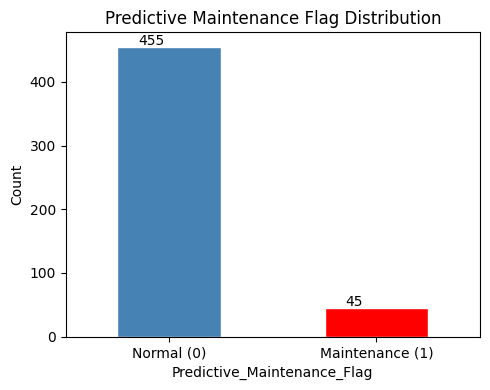

In [ ]:
# Class imbalance check; Predictive Maintenance Flag

flag_counts = df['Predictive_Maintenance_Flag'].value_counts()
print('Maintenance Flag Distribution:')
print(flag_counts)
print(f'\nImbalance ratio: {flag_counts[0]/flag_counts[1]:.1f}:1  (Normal:Maintenance)')

fig, ax = plt.subplots(figsize=(5,4))
flag_counts.plot(kind='bar', ax=ax, color=['steelblue','red'], edgecolor='white')
ax.set_xticklabels(['Normal (0)', 'Maintenance (1)'], rotation=0)
ax.set_title('Predictive Maintenance Flag Distribution')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.1, p.get_height()+3))
plt.tight_layout()
plt.show()

## UNIVARIATE ANALYSIS

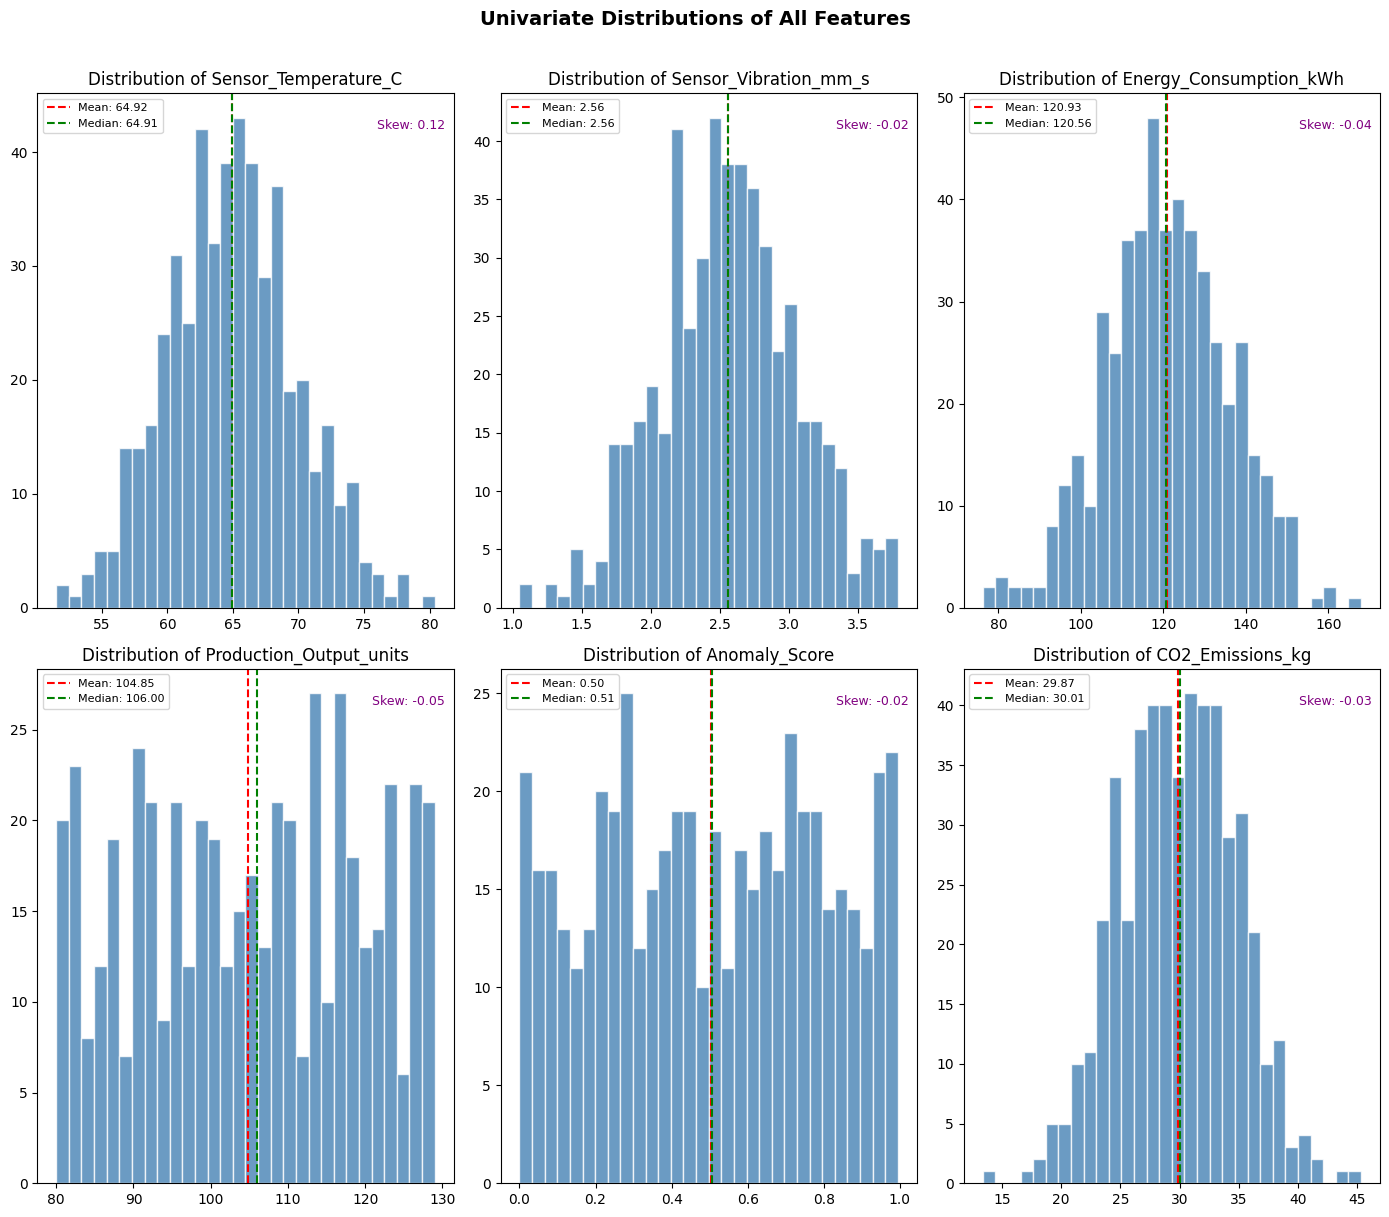

In [ ]:
# Univariate Analysis; distribution of each feature

fig, axes = plt.subplots(2, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')   # red line correspond to mean value
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')   # green line correspond to median value
    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend(fontsize=8)
    # skewness coefficient
    skew = df[col].skew()
    axes[i].text(0.98, 0.95, f'Skew: {skew:.2f}', transform=axes[i].transAxes,    # display skewness coefficient
                 ha='right', va='top', fontsize=9, color='purple')

plt.suptitle('Univariate Distributions of All Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

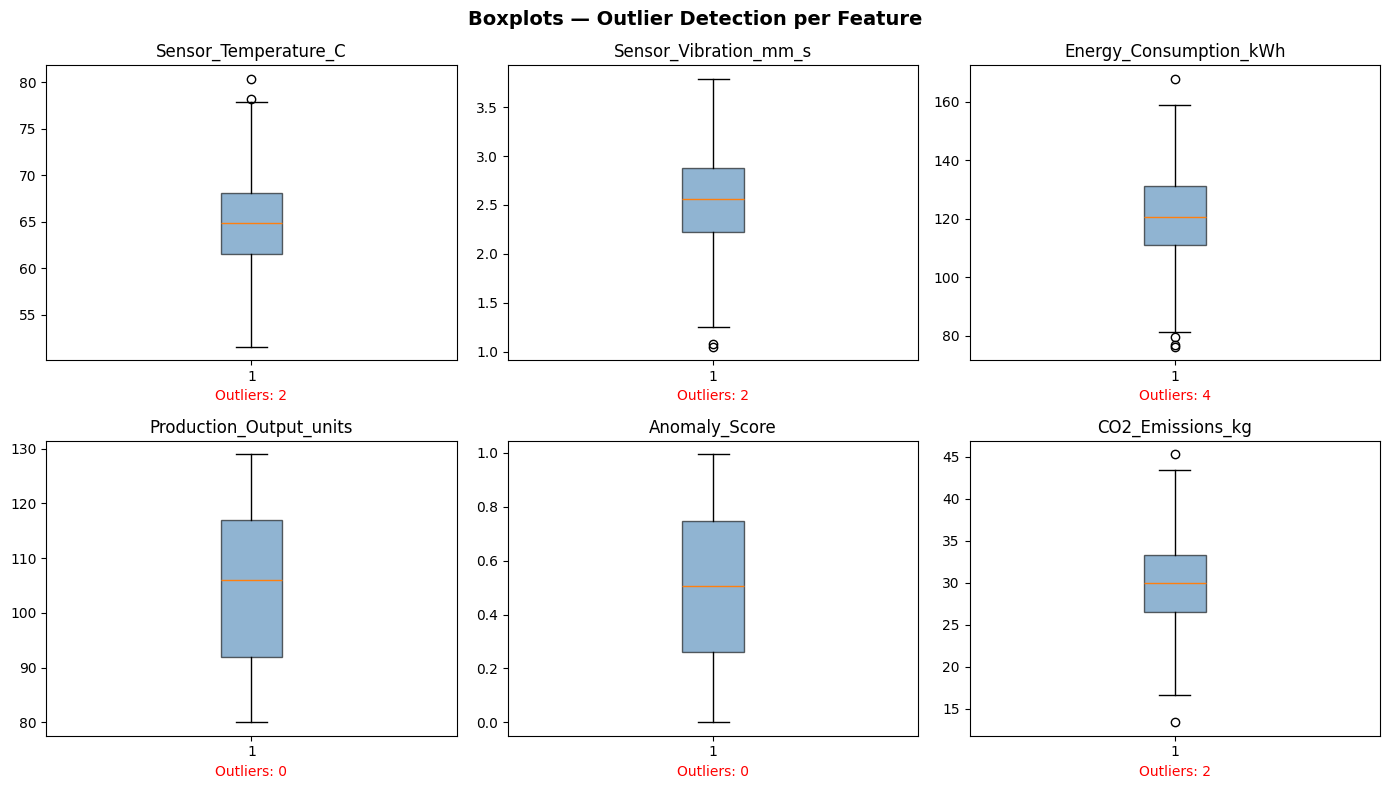

In [ ]:
# Univariate; boxplots to detect outliers

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)
    # Count outliers using IQR
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    axes[i].set_xlabel(f'Outliers: {len(outliers)}', color='red')

plt.suptitle('Boxplots — Outlier Detection per Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

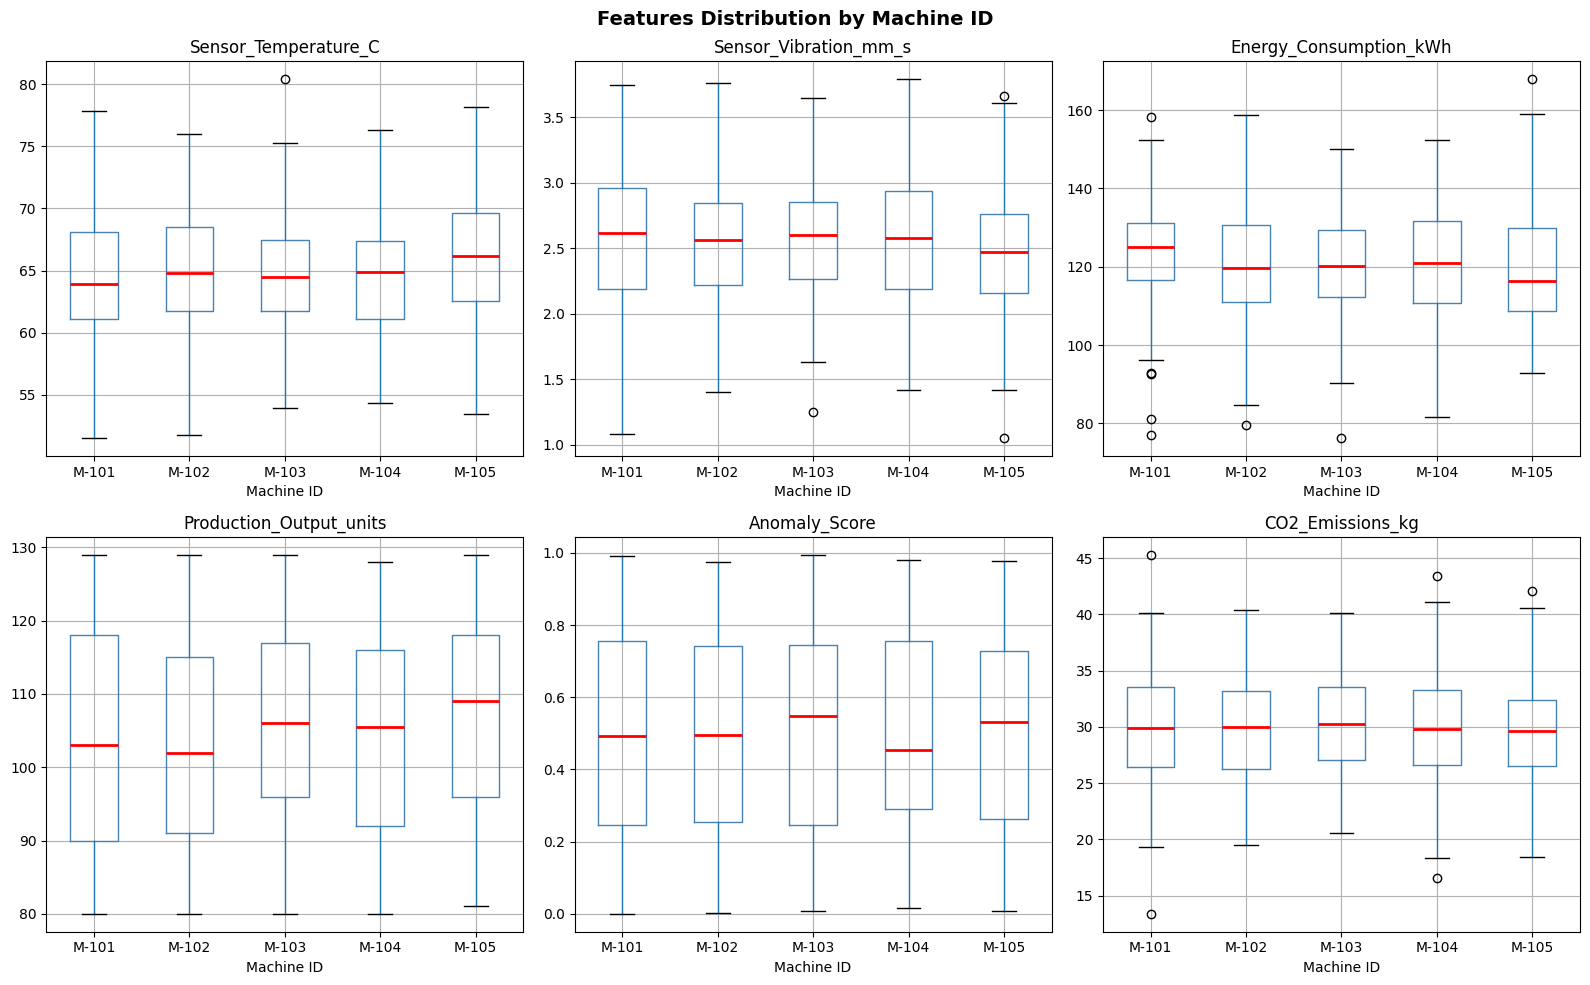

In [ ]:
# Boxplots per machine for all parameters

df = pd.read_csv('AIoT_Industry4_SyntheticDataset.csv')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Machine_ID', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel('Machine ID')

plt.suptitle('Features Distribution by Machine ID', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## BIVARIATE ANALYSIS

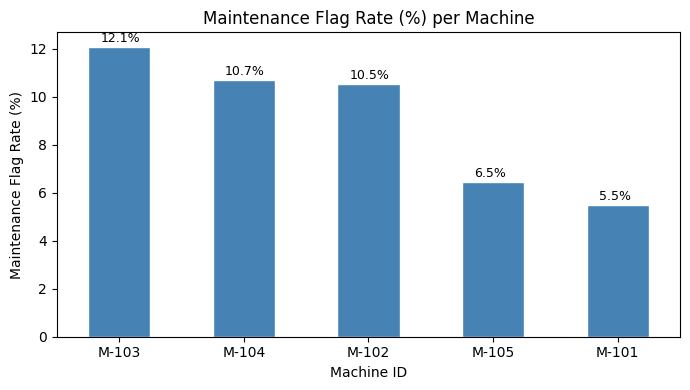

In [ ]:
# Maintenance flag rate per machine
# checking for which machine underwent most frequent maintenance

df = pd.read_csv('AIoT_Industry4_SyntheticDataset.csv')
maint_rate = df.groupby('Machine_ID')['Predictive_Maintenance_Flag'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(7, 4))
maint_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Maintenance Flag Rate (%) per Machine')
ax.set_ylabel('Maintenance Flag Rate (%)')
ax.set_xlabel('Machine ID')
ax.set_xticklabels(maint_rate.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+0.1, p.get_height()+0.2), fontsize=9)
plt.tight_layout()
plt.show()

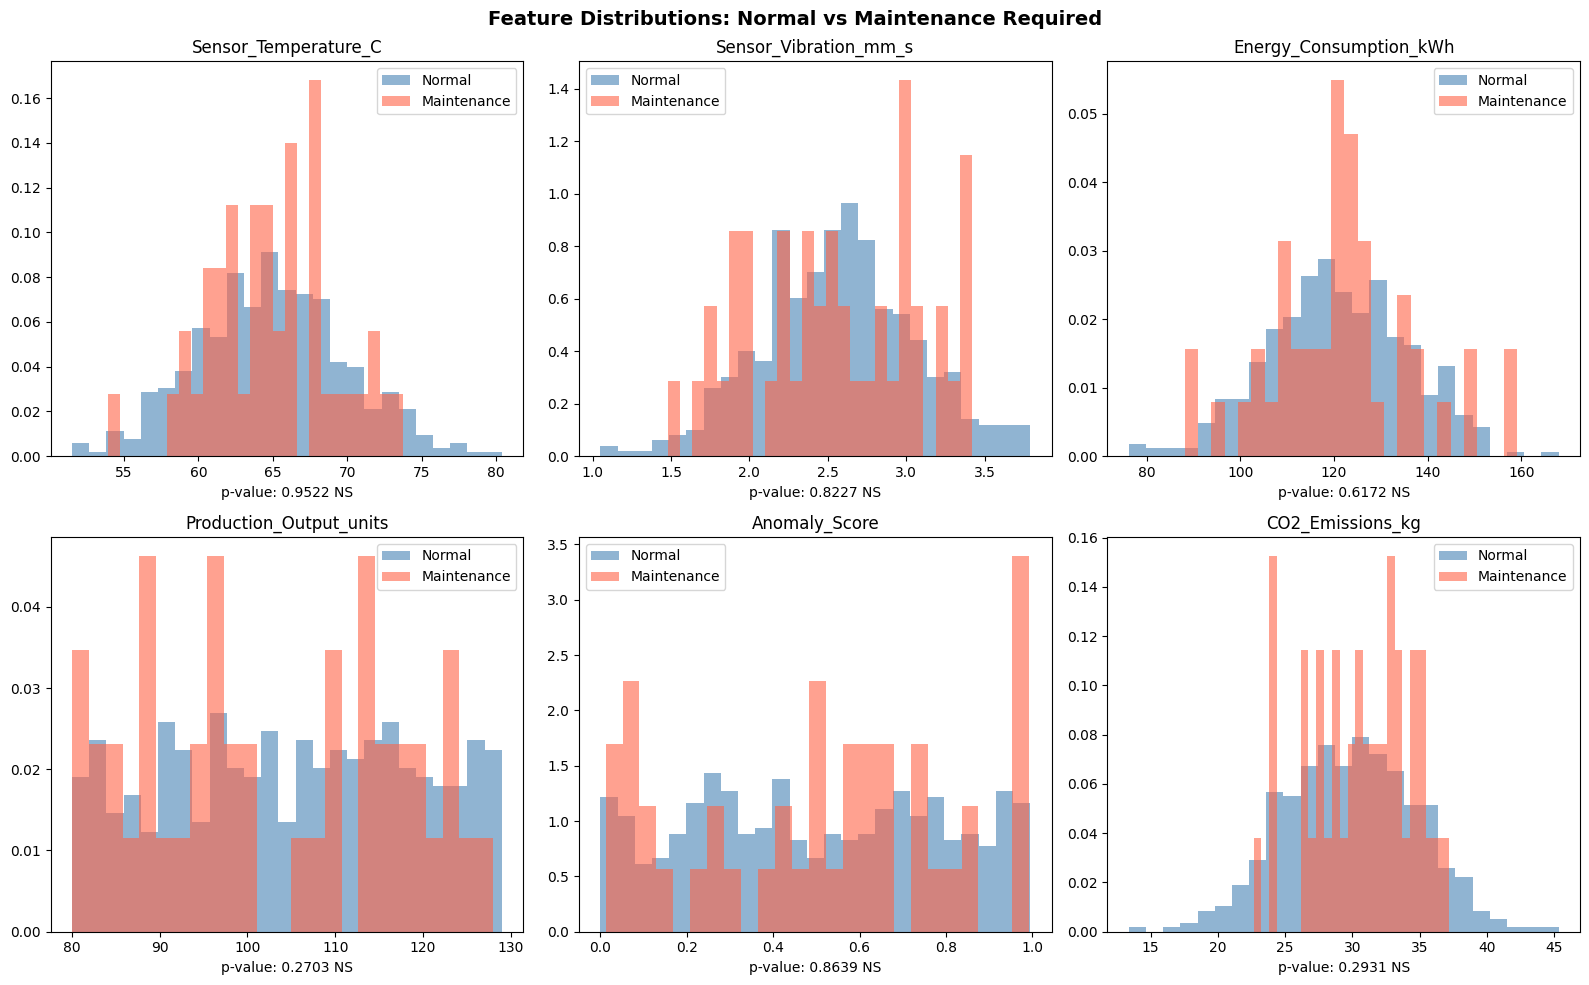

In [ ]:
# Anomaly & Maintenance Flag Analysis
# Feature distributions: Normal vs Maintenance
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

normal = df[df['Predictive_Maintenance_Flag'] == 0]
maint  = df[df['Predictive_Maintenance_Flag'] == 1]

for i, col in enumerate(num_cols):
    axes[i].hist(normal[col], bins=25, alpha=0.6, color='steelblue', label='Normal', density=True)
    axes[i].hist(maint[col],  bins=25, alpha=0.6, color='tomato',    label='Maintenance', density=True)
    axes[i].set_title(col)
    axes[i].legend()

    # T-test --> for statistical testing (checking for significance)
    t, p = stats.ttest_ind(normal[col], maint[col])
    axes[i].set_xlabel(f'p-value: {p:.4f} {"***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "NS"}')

plt.suptitle('Feature Distributions: Normal vs Maintenance Required', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

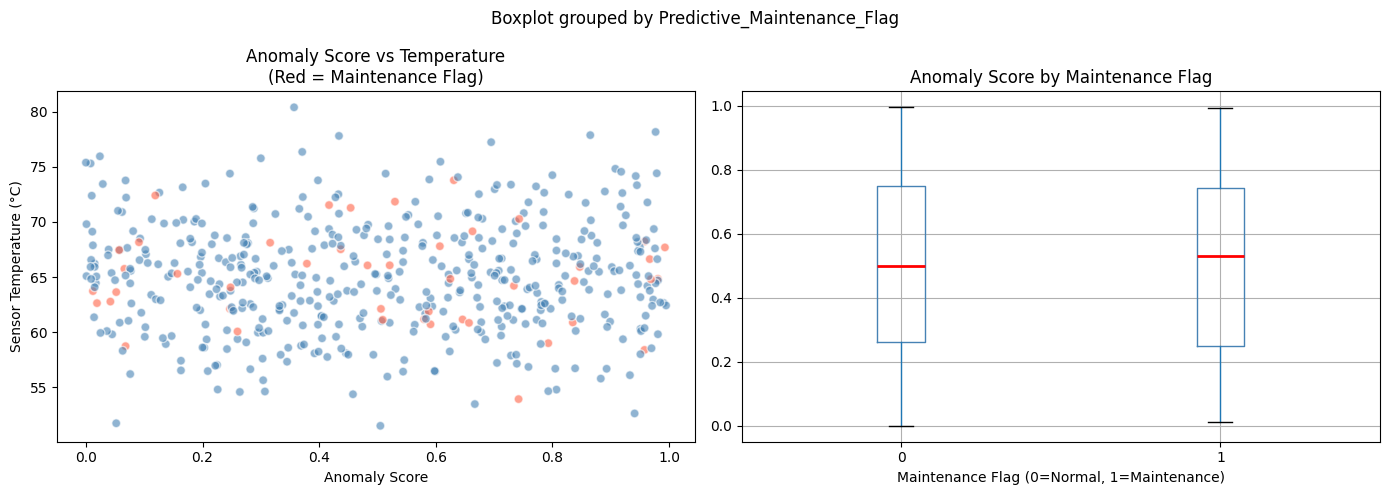

In [ ]:
# Anomaly Score vs Maintenance Flag
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
colors = df['Predictive_Maintenance_Flag'].map({0:'steelblue', 1:'tomato'})
axes[0].scatter(df['Anomaly_Score'], df['Sensor_Temperature_C'],
                c=colors, alpha=0.6, edgecolors='white', s=40)
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Sensor Temperature (°C)')
axes[0].set_title('Anomaly Score vs Temperature\n(Red = Maintenance Flag)')

# Anomaly score by flag
df.boxplot(column='Anomaly_Score', by='Predictive_Maintenance_Flag', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Anomaly Score by Maintenance Flag')
axes[1].set_xlabel('Maintenance Flag (0=Normal, 1=Maintenance)')

plt.tight_layout()
plt.show()

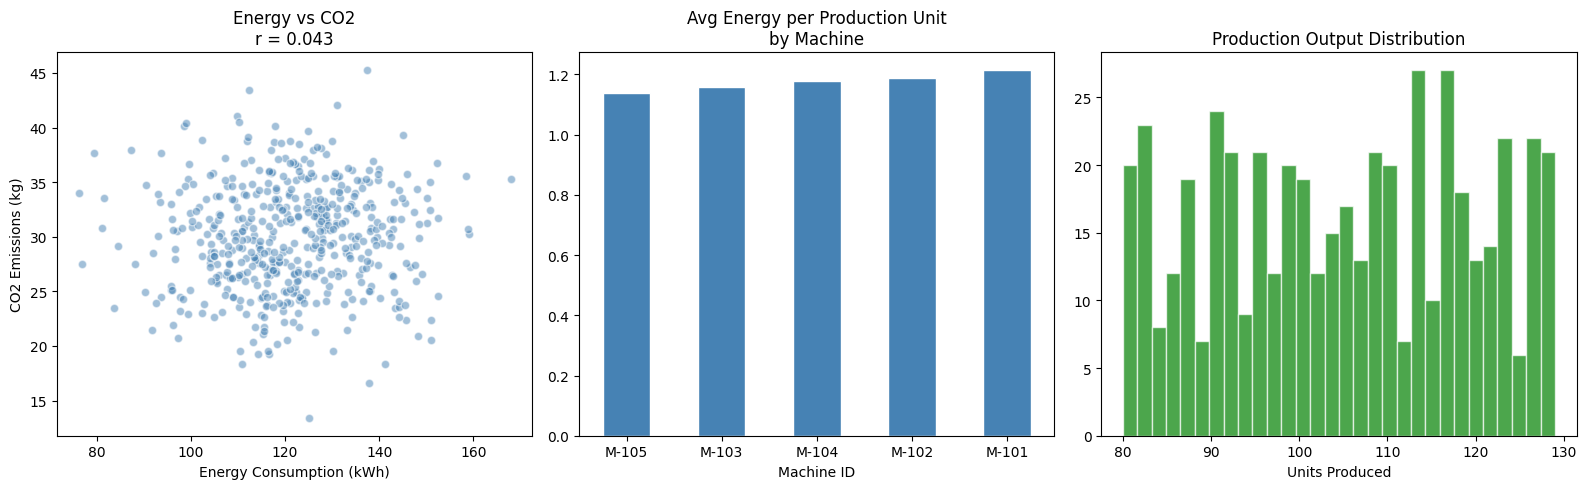

In [ ]:
# Energy vs Production efficiency
df = pd.read_csv('AIoT_Industry4_SyntheticDataset.csv')
df['Energy_per_unit'] = df['Energy_Consumption_kWh'] / df['Production_Output_units']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Energy vs CO2
axes[0].scatter(df['Energy_Consumption_kWh'], df['CO2_Emissions_kg'],
                alpha=0.5, c='steelblue', edgecolors='white')
axes[0].set_xlabel('Energy Consumption (kWh)')
axes[0].set_ylabel('CO2 Emissions (kg)')
axes[0].set_title('Energy vs CO2 Emissions')
r, p = stats.pearsonr(df['Energy_Consumption_kWh'], df['CO2_Emissions_kg'])   # r --> pearson correlation coefficient
axes[0].set_title(f'Energy vs CO2\nr = {r:.3f}')

# Energy efficiency per machine
eff = df.groupby('Machine_ID')['Energy_per_unit'].mean().sort_values()
eff.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Avg Energy per Production Unit\nby Machine')
axes[1].set_xlabel('Machine ID')
axes[1].set_xticklabels(eff.index, rotation=0)

# Production output distribution
axes[2].hist(df['Production_Output_units'], bins=30, color='green', alpha=0.7, edgecolor='white')
axes[2].set_title('Production Output Distribution')
axes[2].set_xlabel('Units Produced')

plt.tight_layout()
plt.show()

## MULTIVARIATE ANALYSIS

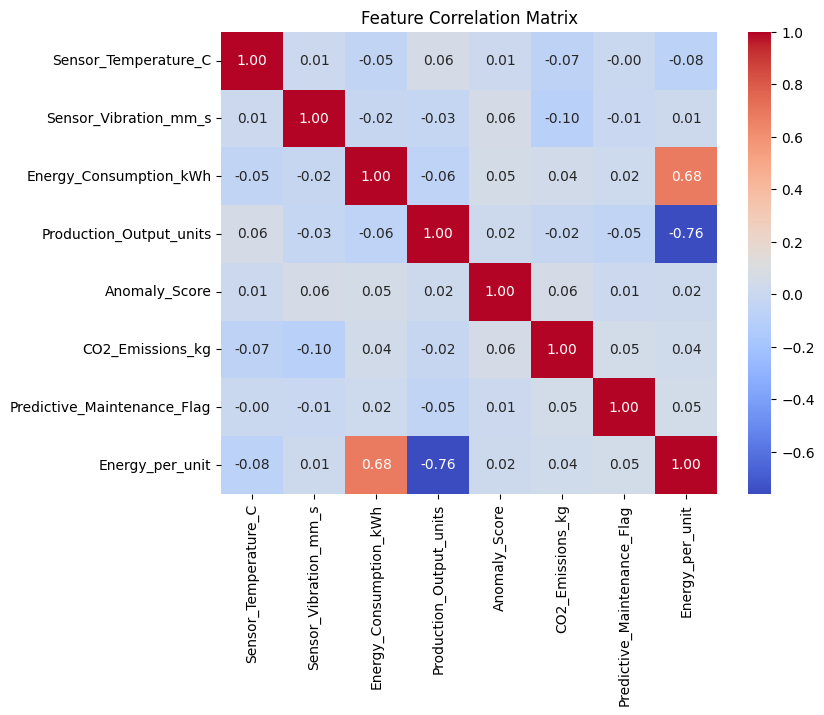

In [ ]:
# multivariate analysis
# Correlation heatmap

df = df.drop(columns=['Timestamp','Machine_ID'])
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

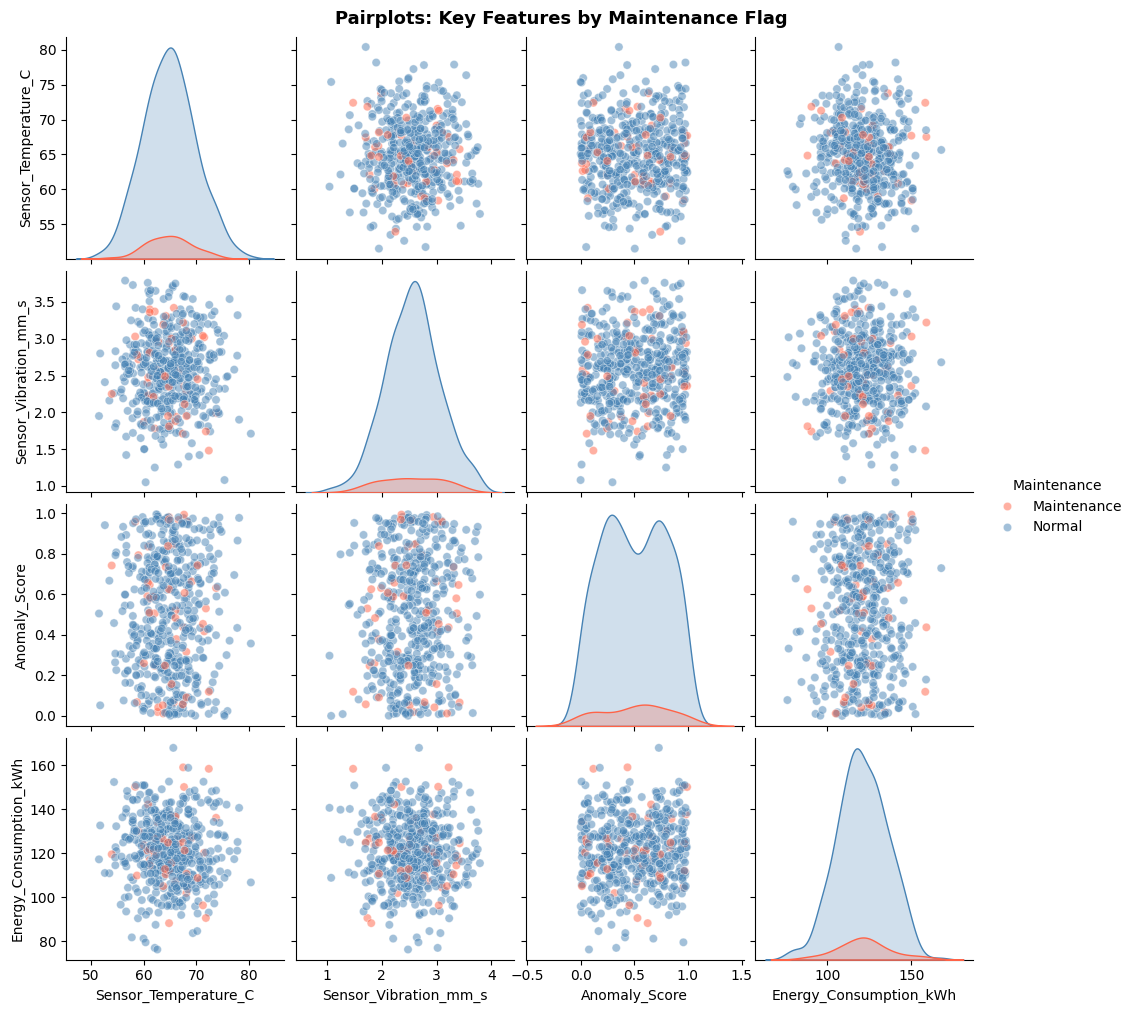

In [ ]:
# PAIRPLOTS

key_cols = ['Sensor_Temperature_C','Sensor_Vibration_mm_s','Anomaly_Score',
            'Energy_Consumption_kWh','Predictive_Maintenance_Flag']
pair_df = df[key_cols].copy()
pair_df['Maintenance'] = pair_df['Predictive_Maintenance_Flag'].map({0:'Normal', 1:'Maintenance'})

sns.pairplot(pair_df.drop('Predictive_Maintenance_Flag', axis=1),
             hue='Maintenance', palette={'Normal':'steelblue','Maintenance':'tomato'},
             diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairplots: Key Features by Maintenance Flag', y=1.01, fontsize=13, fontweight='bold')
plt.show()

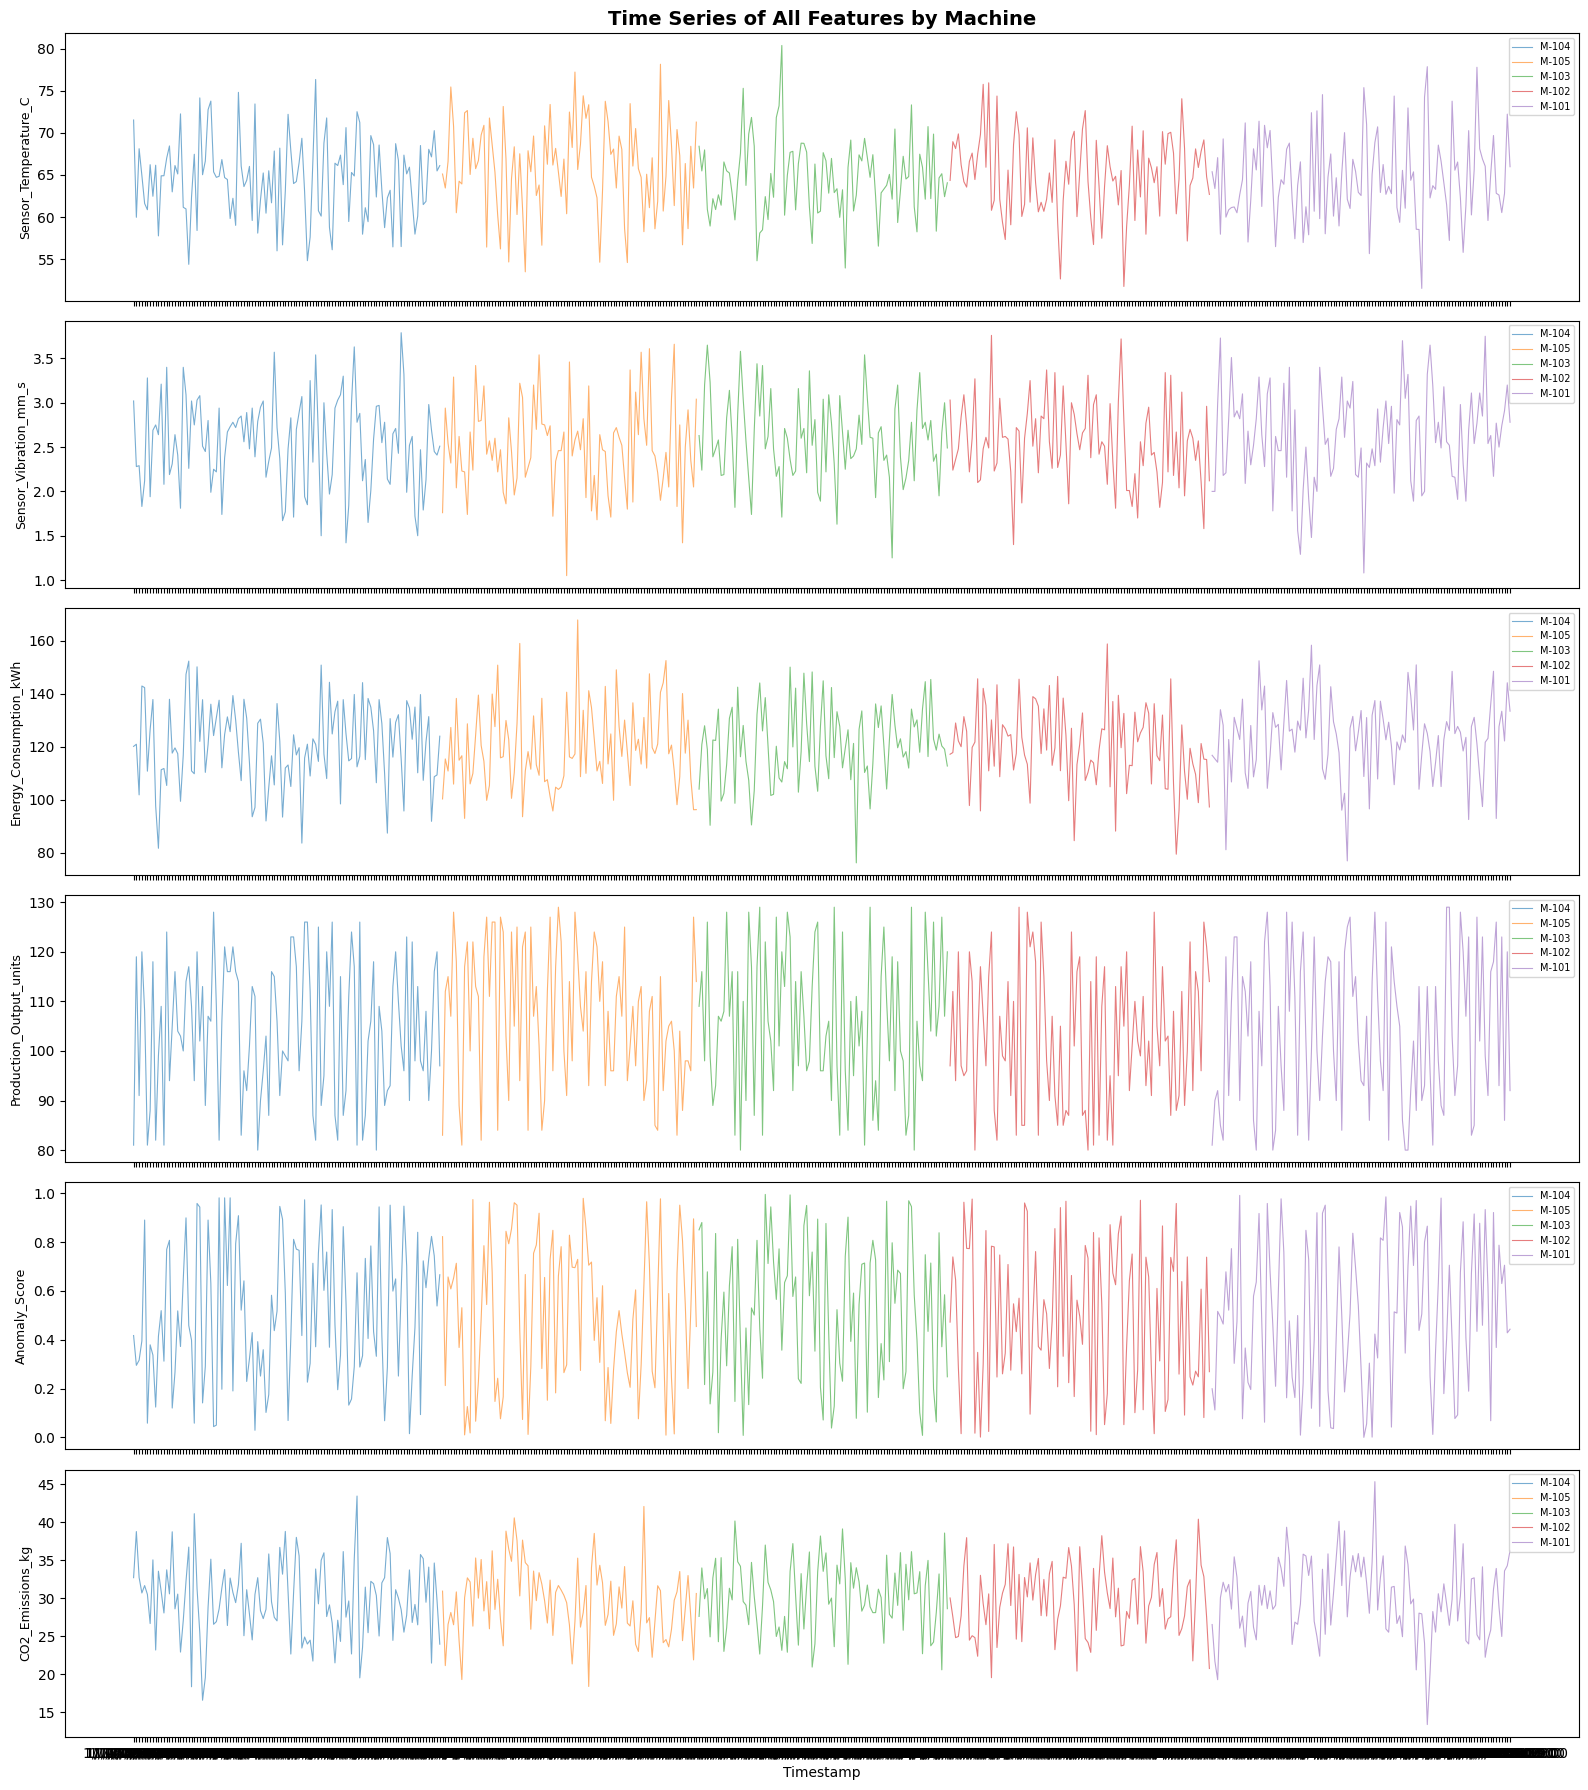

In [ ]:
# Time series analysis

df = pd.read_csv('AIoT_Industry4_SyntheticDataset.csv')
fig, axes = plt.subplots(len(num_cols), 1, figsize=(16, 18), sharex=True)

colors = ['steelblue','darkorange','green','magenta','red']
for i, col in enumerate(num_cols):
    for machine in df['Machine_ID'].unique():
        subset = df[df['Machine_ID'] == machine]
        axes[i].plot(subset['Timestamp'], subset[col], alpha=0.6, linewidth=0.8, label=machine)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].legend(fontsize=7, loc='upper right')

axes[0].set_title('Time Series of All Features by Machine', fontsize=14, fontweight='bold')
axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.show()

## STATISTICAL ANALYSIS


*   One-way ANOVA test: check if there is significant difference in means
*   Assumptions testing: Shapiro-Wilk test, Levene's test
*   Independent t-test; analyse normal features
*   Wilcoxon Rank Sum test: analyse non-normal features



In [ ]:
# Levene test
# to test for homogeneity of variances

IoT_levene = []

print('LEVENE\'S TEST; Across 5 Machines')
print(f"{'Feature':<35} {'F-stat':>9} {'p-value':>12} {'Result':>20}")

for col in  ['Sensor_Temperature_C', 'Sensor_Vibration_mm_s',
            'Energy_Consumption_kWh', 'CO2_Emissions_kg','Production_Output_units','Anomaly_Score']:
    groups = [g[col].values for _, g in df.groupby('Machine_ID')]
    stat, p = levene(*groups, center='mean')
    sig = 'SIGNIFICANT *' if p < 0.05 else 'Homogeneous'
    IoT_levene.append({'Feature': col, 'Stat': stat, 'p': p, 'sig': p < 0.05})
    print(f"{col:<35} {stat:>9.4f} {p:>12.6f} {sig:>20}")

LEVENE'S TEST; Across 5 Machines
Feature                                F-stat      p-value               Result
Sensor_Temperature_C                   0.9592     0.429540          Homogeneous
Sensor_Vibration_mm_s                  0.8544     0.491300          Homogeneous
Energy_Consumption_kWh                 0.4994     0.736167          Homogeneous
CO2_Emissions_kg                       0.2751     0.894021          Homogeneous
Production_Output_units                1.2916     0.272264          Homogeneous
Anomaly_Score                          0.2709     0.896698          Homogeneous


In [ ]:
# Shapiro-Wilk test (Normality test)
# to test the residuals of the models

IoT_ShapiroWilk = []
for col in  ['Sensor_Temperature_C', 'Sensor_Vibration_mm_s',
            'Energy_Consumption_kWh', 'CO2_Emissions_kg','Production_Output_units','Anomaly_Score']:
    stat, p = shapiro(df[col])
    sig = 'Normal' if p > 0.05 else 'Non-normal'
    IoT_ShapiroWilk.append({'Feature': col, 'Stat': stat, 'p': p, 'sig': p > 0.05})
    print(f"{col:<35} {stat:>9.4f} {p:>12.6f} {sig:>20}")

Sensor_Temperature_C                   0.9980     0.836304               Normal
Sensor_Vibration_mm_s                  0.9973     0.585976               Normal
Energy_Consumption_kWh                 0.9982     0.893194               Normal
CO2_Emissions_kg                       0.9980     0.828719               Normal
Production_Output_units                0.9557     0.000000           Non-normal
Anomaly_Score                          0.9541     0.000000           Non-normal


Independent T-test; to test the features that are normally distributed (based on the output of Shapiro-Wilk test)

Ho = Mean of each feature is equal between Normal and Maintenance group

HA = At least 1 mean is significantly different than the rest

In [ ]:
# Independent T-test

normal = df[df['Predictive_Maintenance_Flag'] == 0]
maint  = df[df['Predictive_Maintenance_Flag'] == 1]

IoT_Ttest = []

for col in ['Sensor_Temperature_C', 'Sensor_Vibration_mm_s',
            'Energy_Consumption_kWh', 'CO2_Emissions_kg']:

    stat, p = ttest_ind(normal[col], maint[col], nan_policy='omit')
    sig = 'Significant' if p < 0.05 else 'Not Significant'

    IoT_Ttest.append({'Feature': col, 'Stat': stat, 'p': p, 'sig': p < 0.05})
    print(f"{col:<35} {stat:>9.4f} {p:>12.6f} {sig:>20}")

Sensor_Temperature_C                   0.0600     0.952157      Not Significant
Sensor_Vibration_mm_s                  0.2242     0.822681      Not Significant
Energy_Consumption_kWh                -0.5001     0.617225      Not Significant
CO2_Emissions_kg                      -1.0524     0.293108      Not Significant


Wilcoxon Rank Sum Test (or else known as Mann-Whitney U test): to analyse the features which are not normally distributed based on shapiro-wilk test (production output and anomaly score)

In [ ]:
# Wilcoxon Rank Sum test

IoT_WilcoxonRank = []

for col in ['Production_Output_units', 'Anomaly_Score']:
  stat, p = mannwhitneyu(normal[col], maint[col], alternative='two-sided')
  sig = 'Significant' if p < 0.05 else 'Not Significant'
  IoT_WilcoxonRank.append({'Feature': col, 'Stat': stat, 'p': p, 'sig': p < 0.05})
  print(f"{col:<35} {stat:>9.4f} {p:>12.6f} {sig:>20}")

Production_Output_units             11252.5000     0.272407      Not Significant
Anomaly_Score                       10060.5000     0.848604      Not Significant


In [ ]:
# 1-way ANOVA

df = pd.read_csv('AIoT_Industry4_SyntheticDataset.csv')
for col in ['Sensor_Temperature_C', 'Sensor_Vibration_mm_s',
            'Energy_Consumption_kWh', 'CO2_Emissions_kg','Production_Output_units','Anomaly_Score']:
    groups = [g[col].values for _, g in df.groupby('Machine_ID')]
    F, p = f_oneway(*groups)
    sig = 'Significant' if p < 0.05 else 'Non-Significant'
    groups.append({'Feature': col, 'F-stat': F, 'p': p, 'sig': p < 0.05})
    print(f"{col:<35} {F:>9.4f} {p:>12.6f} {sig:>20}")

Sensor_Temperature_C                   1.4460     0.217624      Non-Significant
Sensor_Vibration_mm_s                  0.6732     0.610804      Non-Significant
Energy_Consumption_kWh                 1.0764     0.367477      Non-Significant
CO2_Emissions_kg                       0.1792     0.949117      Non-Significant
Production_Output_units                1.3634     0.245532      Non-Significant
Anomaly_Score                          0.0986     0.982884      Non-Significant


 KEY FINDINGS BASED ON AIOT INDUSTRY 4.0 DATASET

In [ ]:
print('EDA SUMMARY — AIoT Industry 4.0 Dataset')
print(f'\n Dataset: {df.shape[0]} records, {df.shape[1]} features')
print(f' Time range: {df["Timestamp"].min()} → {df["Timestamp"].max()}')
print(f' Machines: {sorted(df["Machine_ID"].unique())}')
print(f' Missing values: None')
print(f'\n Class Imbalance:')
print(f'   Normal: {(df["Predictive_Maintenance_Flag"]==0).sum()} ({(df["Predictive_Maintenance_Flag"]==0).mean()*100:.1f}%)')
print(f'   Maintenance: {(df["Predictive_Maintenance_Flag"]==1).sum()} ({(df["Predictive_Maintenance_Flag"]==1).mean()*100:.1f}%)')
print(f'\n Correlations with Maintenance Flag:')
corr_target = df[num_cols + ['Predictive_Maintenance_Flag']].corr()['Predictive_Maintenance_Flag'].drop('Predictive_Maintenance_Flag').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    print(f'   {feat:35s}: {val:+.4f}')
print(f'\n Statistical Significance (T-test Normal vs Maintenance):')
for col in num_cols:
    t, p = stats.ttest_ind(normal[col], maint[col])
    sig = '*** (Highly Significant)' if p<0.001 else '** (Significant)' if p<0.01 else '* (Significant)' if p<0.05 else 'Not Significant'
    print(f'   {col:35s}: p={p:.4f}  {sig}')

EDA SUMMARY — AIoT Industry 4.0 Dataset

 Dataset: 500 records, 9 features
 Time range: 1/1/2025 0:00 → 1/9/2025 9:00
 Machines: ['M-101', 'M-102', 'M-103', 'M-104', 'M-105']
 Missing values: None

 Class Imbalance:
   Normal: 455 (91.0%)
   Maintenance: 45 (9.0%)

 Correlations with Maintenance Flag:
   Production_Output_units            : -0.0494
   CO2_Emissions_kg                   : +0.0471
   Energy_Consumption_kWh             : +0.0224
   Sensor_Vibration_mm_s              : -0.0100
   Anomaly_Score                      : +0.0077
   Sensor_Temperature_C               : -0.0027

 Statistical Significance (T-test Normal vs Maintenance):
   Sensor_Temperature_C               : p=0.9522  Not Significant
   Sensor_Vibration_mm_s              : p=0.8227  Not Significant
   Energy_Consumption_kWh             : p=0.6172  Not Significant
   Production_Output_units            : p=0.2703  Not Significant
   Anomaly_Score                      : p=0.8639  Not Significant
   CO2_Emissions_kg 